# Modeling and final evaluation

The preprocessing notebook fixed the input pipeline. This notebook fixes the model. It presents three stages. The first is a grid over four backbones at two frames, which selects the architecture. The second is the final model, the selected architecture retrained on the full training set, examined epoch by epoch. The third is the evaluation of that model on the clinic scans, followed by a diagnosis of where it fails.

Every figure and table below is read from a file written by a script in experiments/. The notebook does not train or evaluate any model. It reads model_results.csv from the grid, checkpoint_eval.csv from the per-epoch evaluation of the final run, and clinic_scan_e1.csv from the per-scan evaluation of the delivered checkpoint.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from ocular import config

EXP = config.ROOT / "experiments"
models = pd.read_csv(EXP / "results" / "model_results.csv")
curve = pd.read_csv(EXP / "results" / "checkpoint_eval.csv").sort_values("epoch").reset_index(drop=True)
clinic = pd.read_csv(EXP / "results" / "clinic_scan_e1.csv")

name = {"custom": "custom", "resnet50": "ResNet50", "convnext_tiny": "ConvNeXt-T", "vit_b_16": "ViT-B"}
metrics = [("octdl_recall_DRUSEN", "DRUSEN recall"), ("octdl_macro_f1", "macro-F1")]

### Reading the implementation inline

Where a step below is explained, the source of the function that implements it is printed directly beneath, read live from the `ocular` package with `inspect.getsource`, so the code shown here is the code that runs and cannot drift from it. The orchestration scripts in `experiments/` and the data plumbing are left in the package and mapped in the README.

In [2]:
import inspect
from IPython.display import display, Code
from ocular import model as omodel, train as otrain, eval as oeval


def show_src(*objs):
    """Display the live source of each function, class or module."""
    for o in objs:
        display(Code(inspect.getsource(o), language="python"))

## What these numbers measure

The grid in the next section is a screen, not a final measurement. Each backbone is trained on a class-balanced subsample of the training set, three thousand images per class, so that four architectures at two frames can be compared within a fixed time budget. The purpose is to rank the architectures against one another, so the scores here are lower than the full-data model that follows and are meaningful only as a comparison between rows.

Two consequences follow. The custom convolutional network is trained from random initialisation, so on this small subsample it is data starved and its score understates what it would reach with more data. It is the floor of the grid, not a fair estimate of a network without pretraining. The pretrained backbones, by contrast, already carry useful features and need less data to adapt, so the subsample penalises them less. Only the selected architecture is retrained on the full training set, and that full-data model is the one reported from the final section onward.

## Model grid

**Method.** Four backbones are compared at the two frames carried forward from the size phase, the square frame and the one and a half to one frame, under the same cropped, curvature-corrected and squished pipeline. The candidates are the custom network, ResNet50, ConvNeXt-Tiny and ViT-B. As before the ranking is drusen recall on the unseen OCTDL set, with macro-F1 as the secondary criterion.

**Finding.** ConvNeXt-Tiny at the one and a half to one frame is the strongest candidate on every metric. Architecture matters for the drusen class in particular. At a matched frame ConvNeXt-Tiny reaches a drusen recall five to ten points above ResNet50, while the two are within about a point on overall accuracy, so the gain is concentrated where it is hardest. ViT-B is the weakest of the pretrained backbones, which is consistent with a supervised transformer being data hungry on a small subsample and with its wrapper resizing the input down to a square. The custom network is the floor, for the reason given above.

In [3]:
frame = models["width"].astype(str) + "x" + models["height"].astype(str)
grid = pd.DataFrame({
    "model": models["model"].map(name),
    "params_M": (models["params"] / 1e6).round(1),
    "frame": frame,
    "octdl_macro_f1": models["octdl_macro_f1"].round(3),
    "octdl_drusen_recall": models["octdl_recall_DRUSEN"].round(3),
    "clinic_acc": models["clinic_acc"].round(3),
})
grid.sort_values(["frame", "octdl_drusen_recall"], ascending=[True, False]).reset_index(drop=True)

,model,params_M,frame,octdl_macro_f1,octdl_drusen_recall,clinic_acc
0,ConvNeXt-T,27.8,256x256,0.913,0.724,0.649
1,ResNet50,23.5,256x256,0.901,0.667,0.649
2,ViT-B,85.8,256x256,0.867,0.604,0.595
3,custom,1.2,256x256,0.785,0.583,0.351
4,ConvNeXt-T,27.8,384x256,0.917,0.766,0.703
5,ResNet50,23.5,384x256,0.891,0.661,0.595
6,custom,1.2,384x256,0.815,0.516,0.405
7,ViT-B,85.8,384x256,0.802,0.391,0.405


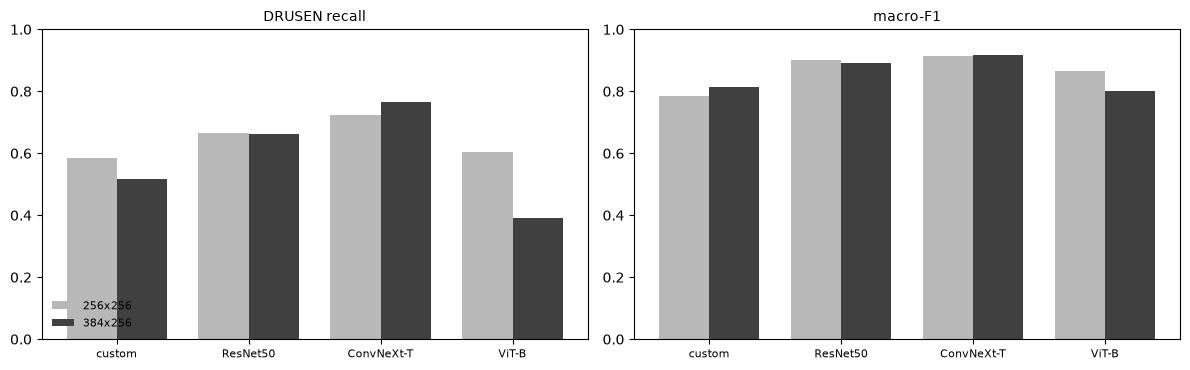

In [4]:
# each backbone at the two frames, drusen recall and macro-F1
model_order = ["custom", "resnet50", "convnext_tiny", "vit_b_16"]
piv = {m: models[models["model"] == m].set_index("width") for m in model_order}
x = np.arange(len(model_order))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (col, label) in zip(axes, metrics):
    ax.bar(x - w / 2, [piv[m].loc[256, col] for m in model_order], w, label="256x256", color="0.72")
    ax.bar(x + w / 2, [piv[m].loc[384, col] for m in model_order], w, label="384x256", color="0.25")
    ax.set_xticks(x)
    ax.set_xticklabels([name[m] for m in model_order], fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1)
axes[0].legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

In [5]:
show_src(omodel.build_model, omodel.CustomCNN)

def build_model(
    arch: str = "resnet50",
    num_classes: int = len(config.CLASSES),
    pretrained: bool = True,
) -> nn.Module:
    """Build a backbone with a fresh classification head.

    Parameters
    ----------
    arch : str, optional
        Architecture name, one of :data:`ARCHS`.
    num_classes : int, optional
        Number of output classes.
    pretrained : bool, optional
        Whether to initialise the backbone from its default pretrained weights.
        Ignored for the custom network, which is always trained from scratch.

    Returns
    -------
    torch.nn.Module
        The model with a classification head of ``num_classes`` outputs.

    Raises
    ------
    ValueError
        If ``arch`` is not in :data:`ARCHS`.
    """
    if arch == "custom":
        return CustomCNN(num_classes=num_classes)
    if arch not in ARCHS:
        raise ValueError(f"unknown arch {arch!r}, expected one of {ARCHS}")

    weights = "DEFAULT" if pretrained else None
    model = getattr(tvm, arch)(weights=weights)

    if arch.startswith("resnet"):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif arch.startswith("efficientnet") or arch == "convnext_tiny":
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif arch == "vit_b_16":
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif arch == "swin_t":
        model.head = nn.Linear(model.head.in_features, num_classes)
    elif arch == "densenet121":
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

class CustomCNN(nn.Module):
    """A small convolutional network trained from scratch.

    The network is four convolutional blocks followed by global average pooling
    and a linear head, giving roughly one to three million parameters. It is the
    no-pretraining anchor of the pretraining comparison.

    Parameters
    ----------
    num_classes : int, optional
        Number of output classes.
    in_channels : int, optional
        Number of input channels. The data pipeline serves three channels, so
        the default matches the pretrained backbones.
    """

    def __init__(self, num_classes: int = len(config.CLASSES), in_channels: int = 3) -> None:
        super().__init__()

        def block(i: int, o: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1),
                nn.BatchNorm2d(o),
                nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1),
                nn.BatchNorm2d(o),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(in_channels, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

## The final model, trained on full data

**Method.** The selected configuration, ConvNeXt-Tiny at the one and a half to one frame, is retrained on the full training set of seventy three thousand images with class weights active. A checkpoint is saved after every epoch, and each checkpoint is scored on three sets, the Kermany validation split, the unseen OCTDL set and the clinic scans. The curve below reads those scores from checkpoint_eval.csv.

**Finding.** The best transfer is at the first epoch. On the unseen OCTDL set both the macro-F1 and the drusen recall are highest at epoch one, at about 0.93 and 0.83, and every later epoch sits below that, with the drusen recall never returning to its first-epoch value. The clinic accuracy is also at its best at the first epoch. The Kermany validation score behaves in the opposite way. It is at its lowest at the first epoch and sits higher at every later one, so the epoch with the strongest transfer is the epoch with the weakest validation score. This is source-domain overfitting. The model keeps fitting the training distribution while its features specialise to that distribution and transfer less well to an unseen device, and the validation score, measured on that same distribution, cannot see the loss. It is therefore anti-predictive of transfer here and cannot be used to choose the model.

**Recipe, not selection.** The honest reading is that the training schedule should be short, on the order of a single epoch, decided in advance from this behaviour rather than by reading the epoch with the best OCTDL score off the curve. Choosing the epoch from OCTDL or from the clinic would turn a held-out set into a training signal and inflate the reported result. The first-epoch checkpoint is delivered because the recipe is one epoch, not because it won a comparison on the evaluation sets.

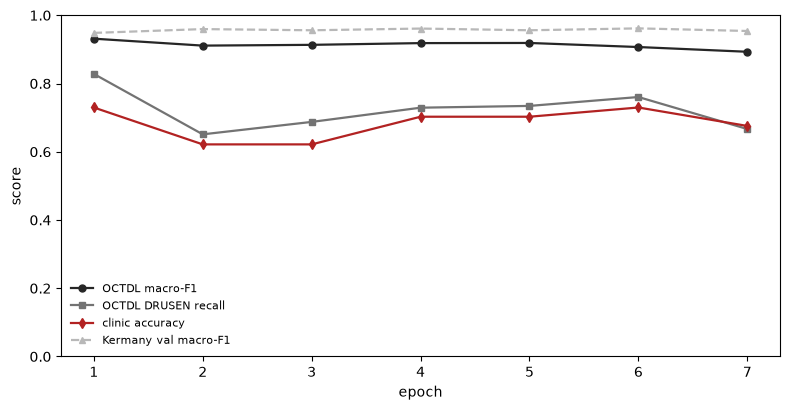

In [6]:
c = curve
styles = [
    ("octdl_macro_f1", "OCTDL macro-F1", "o-", "0.15"),
    ("octdl_recall_DRUSEN", "OCTDL DRUSEN recall", "s-", "0.45"),
    ("clinic_acc", "clinic accuracy", "d-", "#b22222"),
    ("val_macro_f1", "Kermany val macro-F1", "^--", "0.72"),
]
fig, ax = plt.subplots(figsize=(8, 4.2))
for col, label, style, color in styles:
    ax.plot(c["epoch"], c[col], style, label=label, color=color, linewidth=1.6, markersize=5)
ax.set_xlabel("epoch")
ax.set_ylabel("score")
ax.set_xticks(c["epoch"])
ax.set_ylim(0, 1)
ax.legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

In [7]:
show_src(otrain.train)

def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader | None = None,
    *,
    weights: torch.Tensor | None = None,
    epochs: int = 8,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    device: torch.device | None = None,
    ckpt: str | Path | None = None,
    progress: bool = True,
) -> tuple[nn.Module, list[dict]]:
    """Fit a model and return it together with a training history.

    Parameters
    ----------
    model : torch.nn.Module
        The model to train. It is moved to ``device`` in place.
    train_loader : torch.utils.data.DataLoader
        Training loader.
    val_loader : torch.utils.data.DataLoader, optional
        Validation loader used to record accuracy each epoch. No checkpoint is
        selected from it.
    weights : torch.Tensor, optional
        Per-class weights for the cross-entropy loss, addressing the class
        imbalance.
    epochs : int, optional
        Number of training epochs.
    lr : float, optional
        Learning rate for the AdamW optimiser.
    weight_decay : float, optional
        Weight decay for the optimiser.
    device : torch.device, optional
        Device to train on. Defaults to :func:`get_device`.
    ckpt : str or pathlib.Path, optional
        If given, the final model state dictionary is written here.
    progress : bool, optional
        Whether to show a per-epoch progress bar.

    Returns
    -------
    tuple of (torch.nn.Module, list of dict)
        The trained model and a list of per-epoch records, each with the keys
        ``epoch``, ``train_loss``, and ``val_acc``.
    """
    device = device or get_device()
    model = model.to(device)
    weight = weights.to(device) if weights is not None else None
    criterion = nn.CrossEntropyLoss(weight=weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history: list[dict] = []
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        batches = train_loader
        if progress:
            batches = tqdm(train_loader, desc=f"epoch {epoch}/{epochs}", leave=False)
        for xb, yb in batches:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(yb)

        train_loss = running / len(train_loader.dataset)
        val_acc = _val_accuracy(model, val_loader, device) if val_loader is not None else None
        history.append({"epoch": epoch, "train_loss": train_loss, "val_acc": val_acc})
        if progress:
            msg = f"epoch {epoch}/{epochs}  train_loss {train_loss:.4f}"
            if val_acc is not None:
                msg += f"  val_acc {val_acc:.4f}"
            print(msg)

    if ckpt is not None:
        ckpt = Path(ckpt)
        ckpt.parent.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), ckpt)
    return model, history

## Clinic evaluation

**Method.** The delivered checkpoint is evaluated on the clinic set, thirty seven B-scans exported from a different device than either training or OCTDL. The confusion matrix and the per-class recall below are read from clinic_scan_e1.csv, one row per scan. The clinic set is small and confirms the model rather than selecting it.

**Finding.** The model is correct on twenty seven of the thirty seven scans. The three classes that carry an anatomical signal visible at this resolution are recovered in full, with CNV, DME and NORMAL all classified correctly. Every one of the ten errors falls on the drusen class, where twelve of twenty two scans are recovered. The failure is concentrated entirely in the one class defined by the finest structure.

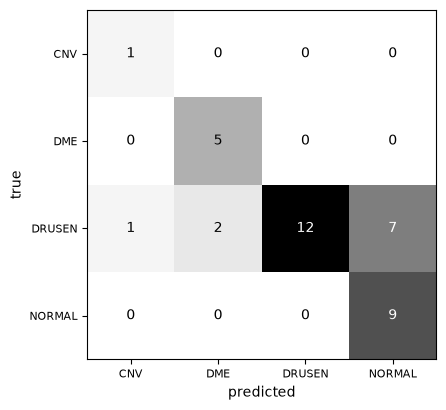

,class,correct,n,recall
0,CNV,1,1,1.000
1,DME,5,5,1.000
2,DRUSEN,12,22,0.545
3,NORMAL,9,9,1.000


In [8]:
labels = config.CLASSES
cm = confusion_matrix(clinic["truth"], clinic["pred"], labels=labels)

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.imshow(cm, cmap="Greys")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=10,
                color="white" if v > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

recall = pd.DataFrame({
    "class": labels,
    "correct": cm.diagonal(),
    "n": cm.sum(axis=1),
    "recall": (cm.diagonal() / cm.sum(axis=1)).round(3),
})
recall

In [9]:
show_src(oeval.predict, oeval.metrics, oeval.evaluate)

@torch.no_grad()
def predict(
    model: nn.Module, loader: DataLoader, device: torch.device | None = None
) -> tuple[np.ndarray, np.ndarray]:
    """Return the true and predicted labels for a loader.

    Parameters
    ----------
    model : torch.nn.Module
        The trained model.
    loader : torch.utils.data.DataLoader
        Loader over the evaluation set.
    device : torch.device, optional
        Device to run on. Defaults to :func:`ocular.train.get_device`.

    Returns
    -------
    tuple of numpy.ndarray
        The true labels and the predicted labels, as integer arrays.
    """
    device = device or get_device()
    model = model.to(device)
    model.eval()
    trues, preds = [], []
    for xb, yb in loader:
        pred = model(xb.to(device)).argmax(1).cpu()
        trues.append(yb)
        preds.append(pred)
    return torch.cat(trues).numpy(), torch.cat(preds).numpy()

def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Compute accuracy, macro-F1, and per-class recall.

    Parameters
    ----------
    y_true : numpy.ndarray
        True integer labels.
    y_pred : numpy.ndarray
        Predicted integer labels.

    Returns
    -------
    dict of str to float
        Keys are ``accuracy``, ``macro_f1``, and ``recall_<CLASS>`` for every
        class in ``config.CLASSES``. Classes absent from ``y_true`` report a
        recall of zero rather than raising.
    """
    labels = list(range(len(config.CLASSES)))
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
    }
    recalls = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    for cls, r in zip(config.CLASSES, recalls):
        out[f"recall_{cls}"] = float(r)
    return out

def evaluate(
    model: nn.Module, loader: DataLoader, device: torch.device | None = None
) -> dict[str, float]:
    """Run a model over a loader and return its metrics.

    Parameters
    ----------
    model : torch.nn.Module
        The trained model.
    loader : torch.utils.data.DataLoader
        Loader over the evaluation set.
    device : torch.device, optional
        Device to run on.

    Returns
    -------
    dict of str to float
        The metrics returned by :func:`metrics`.
    """
    y_true, y_pred = predict(model, loader, device)
    return metrics(y_true, y_pred)

## Diagnosing the drusen misses

**Question.** The drusen recall is the one weak number, so the useful question is whether the misses are near the decision boundary, which a threshold could recover, or whether the model sees no drusen signal at all, which a threshold cannot.

**Finding.** The misses are not close calls. Sorting the drusen scans by the probability the model assigns to the drusen class, the correctly classified scans sit high while most of the missed scans sit very low, with the probability of the true class at or below about one tenth for the majority of the misses to normal. The model is confidently reading these scans as healthy. That points away from the threshold and toward the input. A single low-resolution printed B-scan can lose the small drusen peaks during export and preprocessing, or the printed slice may not cross the lesion at all, so the signal is absent rather than merely weak.

**Consequence.** Moving the decision threshold cannot recover a signal that is not present. The levers that can are on the data side, a higher-resolution export of the full volume rather than a single printed slice, and aggregation of the prediction across the slices of a volume so that a scan that does cross the lesion can carry the case.

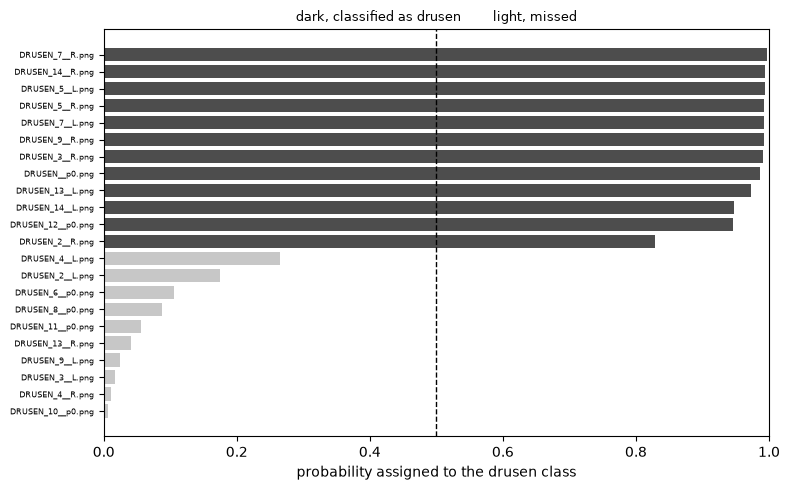

In [10]:
dru = clinic[clinic["truth"] == "DRUSEN"].sort_values("p_DRUSEN").reset_index(drop=True)
hit = (dru["pred"] == "DRUSEN").to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(np.arange(len(dru)), dru["p_DRUSEN"],
        color=["0.30" if h else "0.78" for h in hit])
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(len(dru)))
ax.set_yticklabels(dru["name"], fontsize=6)
ax.set_xlabel("probability assigned to the drusen class")
ax.set_xlim(0, 1)
ax.set_title("dark, classified as drusen        light, missed", fontsize=9)
plt.tight_layout()
plt.show()

## The deliverable

The delivered model is ConvNeXt-Tiny at the one and a half to one frame, trained for one epoch on the full training set under the cropped, curvature-corrected and squished pipeline, saved as experiments/convnext_final_e1.pt. On the unseen OCTDL set it reaches a macro-F1 of about 0.93 with a drusen recall of about 0.83, and on the clinic scans it is correct on twenty seven of thirty seven. Its one weakness, the drusen class on the clinic device, is understood. It is a resolution and volume limitation of the single exported slice rather than a threshold or model fault, and the way to close it is a fuller export and patient-level aggregation rather than more training on the current source.